# ПРИМЕР 1

## Простая модель от одного насоса к одному стволу

![модель НРС](imgs/nrs_simple_1.jpg)


Схема НРС состоит из:
* 1 источника в виде насоса ПА
* 1 рабочей рукавной линии
* 1 прибора подачи воды

In [1]:
from nrs import EType, NRS_Model, Element, NRS_Revision, NRS_Observer_E    # классы НРС
from nrs import NRS_Data as nd                                             # Табличные данные НРС
from nrs import q_out_nozzle                                               # модели расчета параметров
import matplotlib.pyplot as plt                                            # библиотеки для отрисовки получаемых данных

In [2]:
# Вычисляем проводимость насадка для ствола Б
p_nozzleB = NRS_Revision.calc_p(3.7, 40)
p_nozzleB

0.5850213671311502

In [3]:
# Создаем элементы НРС
pump    = Element('Насос',                    e_type = EType.PUMP,      H_add = 20)                                # Стартовый напор на насосе = 20м                     
hoseW1  = Element('Рабочая рукавная линия 1', e_type = EType.CONNECTOR, s = nd.ss["51"], n = 10)                   # Рукава 51мм, кол-во рукавов=10
nozzle1 = Element('Ствол 1',                  e_type = EType.NOZZLE,    p = p_nozzleB,   q_out = q_out_nozzle)     # Для ствола указываем проводимость рассчитанную ранее (p_nozzleB) и метод расчета q_out_nozzle

# Соединяем элементы друг с другом Насос -> Рукавная линия -> Ствол
pump.append(hoseW1).append(nozzle1)

# Добавляем наблюдателей
watcher_pump    = NRS_Observer_E(pump, ['q', 'H_add'])         # Для насоса. Наблюдаем изменения расхода и дополнительного напора (создаваемого насосом)
watcher_nozzle1 = NRS_Observer_E(nozzle1, ['q', 'H_in'])       # Для ствола. Наблюдаем изменения расхода и напора на входе

# Строим модель и инициируем обозревателей
model = NRS_Model('Простая модель от одного насоса к одному стволу')
model = model.build(pump, interpretate=True).observersInit()

In [4]:
# Печатаем состав модели
NRS_Revision.print_model_elements(model)

Простая модель от одного насоса к одному стволу
all:
  Насос
  Рабочая рукавная линия 1
  Ствол 1
in:
  Насос
out:
  Ствол 1


In [5]:
# Печать предыдущего элемента для ствола nozzle1
NRS_Revision.print_previous_elements(nozzle1)

Рабочая рукавная линия 1


In [6]:
# Печать состояния элемента
NRS_Revision.print_element_state(nozzle1)

elements_next: []
elements_previous: [<nrs.Element object at 0x0000023E563CDCD0>]
type: 2
name: Ствол 1
q: 3.7
s: 0
H_in: 0
h: 0
z: 0
p: 0.5850213671311502
n: 1
q_out: <function q_out_nozzle at 0x0000023E563F1080>
H_add: 0
observer: <nrs.NRS_Observer_E object at 0x0000023E563B9EE0>
l: 0
ri: 1
ro: 1


In [7]:
# Расчет
model, result = model.calc(accuracy=0.05)
print('Итераций потребовалось:', result['iters'])
print('Невязка модели:        ', result['QD2'])

Итераций потребовалось: 7
Невязка модели:         0.02300656974704829


In [8]:
# Печать итоговой производительности всей системы
print(model.summaryQ(), 'л/с')

2.16941691901252 л/с


In [9]:
# Рассчитываем (для 10 итераций)
model.calc(iters=10)

(<nrs.NRS_Model at 0x23e563b8860>, 7.008021013721333e-06)

In [10]:
# Получаем текущий суммарный расход НРС
print(model.summaryQ(), 'л/с')

2.1765249153046957 л/с


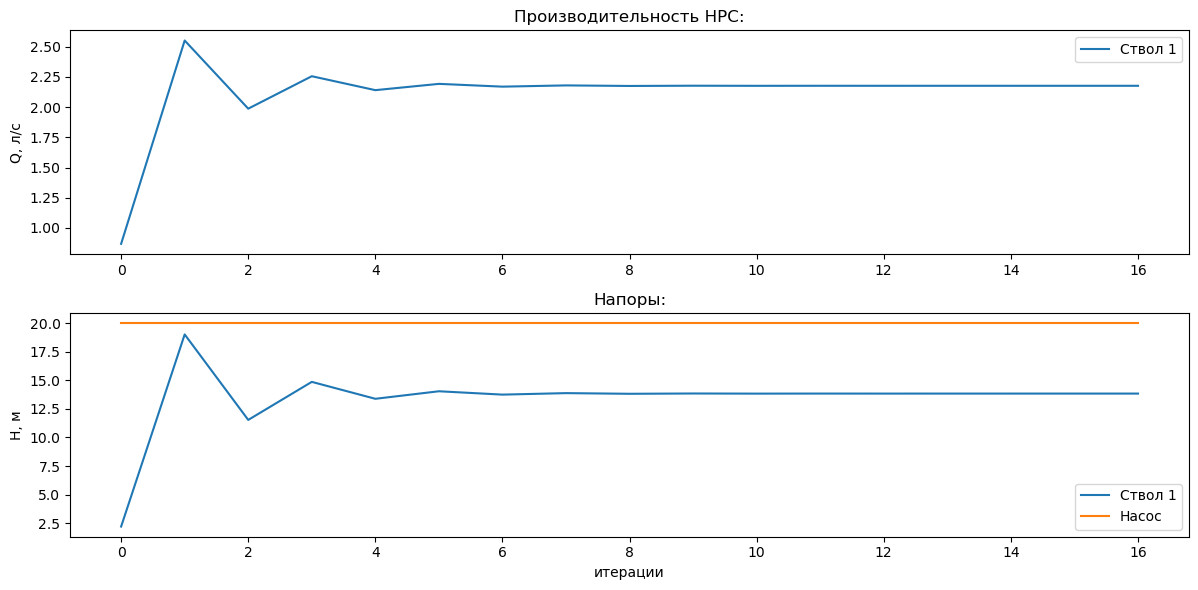

In [11]:
# Выведем графики
fig, axs = plt.subplots(2, 1, figsize=(12, 6))
axs[0].plot(watcher_nozzle1.history()['q'], label=nozzle1.name)
axs[0].set_title('Производительность НРС:')
axs[0].set_ylabel('Q, л/с')
axs[0].legend(fontsize=10)

axs[1].plot(watcher_nozzle1.history()['H_in'], label=nozzle1.name)
axs[1].plot(watcher_pump.history()['H_add'], label=pump.name, )
axs[1].set_title('Напоры:')
axs[1].set_xlabel('итерации')
axs[1].set_ylabel('Н, м')
axs[1].legend(fontsize=10)

fig.tight_layout()
plt.show()

In [12]:
# Постепенно повысим напоры на насосе. 
# Сначала до 40м, затем до 80м. 
# Для каждого повышения проведем расчет на 10 итерациях.
# Результат округлим до 3 знаков после запятой.
pump.set_H_add(40)
model.calc(10)
print(round(model.summaryQ(), 3), 'л/с')
pump.set_H_add(80)
model.calc(10)
print(round(model.summaryQ(), 3), 'л/с')

3.078 л/с
4.353 л/с


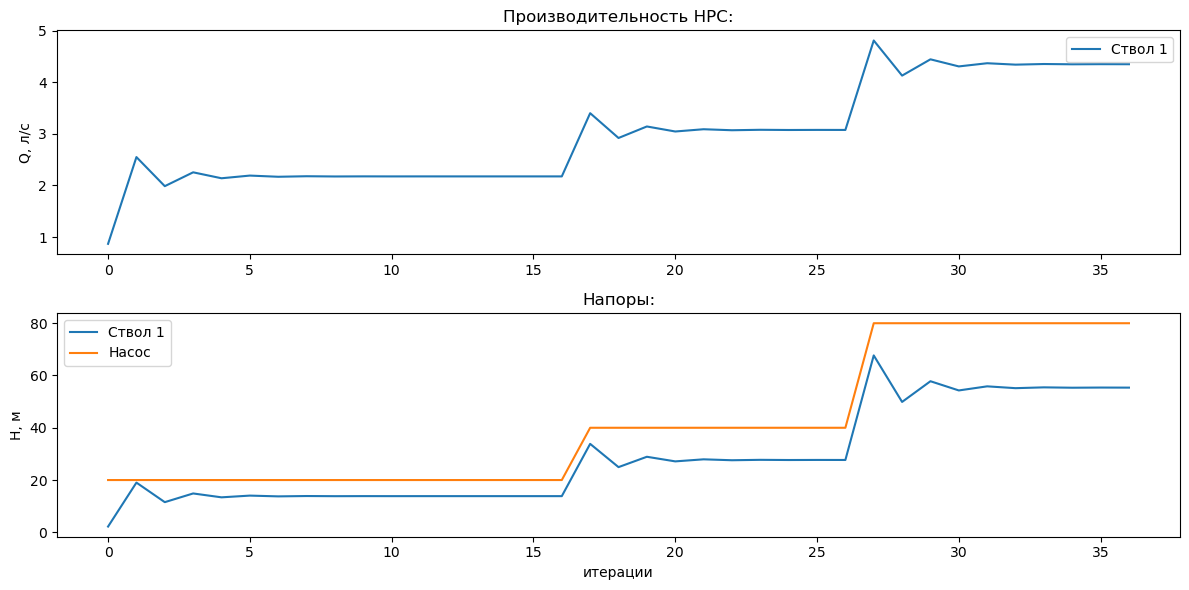

In [13]:
# Выведем графики
fig, axs = plt.subplots(2, 1, figsize=(12, 6))
axs[0].plot(watcher_nozzle1.history()['q'], label=nozzle1.name)
axs[0].set_title('Производительность НРС:')
axs[0].set_ylabel('Q, л/с')
axs[0].legend(fontsize=10)

axs[1].plot(watcher_nozzle1.history()['H_in'], label=nozzle1.name)
axs[1].plot(watcher_pump.history()['H_add'], label=pump.name, )
axs[1].set_title('Напоры:')
axs[1].set_xlabel('итерации')
axs[1].set_ylabel('Н, м')
axs[1].legend(fontsize=10)

fig.tight_layout()
plt.show()

## Расчет до достижения необходимой точности

In [14]:
# Сбрасываем историю расчета
# model.observersInit()

# Устанавливаем напор на насосе
pump.set_H_add(90)
# Рассчитываем для точности 0.005л/с
_, result = model.calc(accuracy=0.005)
print(f"Итоговый расход: {round(model.summaryQ(), 2)} л/с")
print(f"Потребовалось итераций: {result['iters']}")

Итоговый расход: 4.62 л/с
Потребовалось итераций: 7


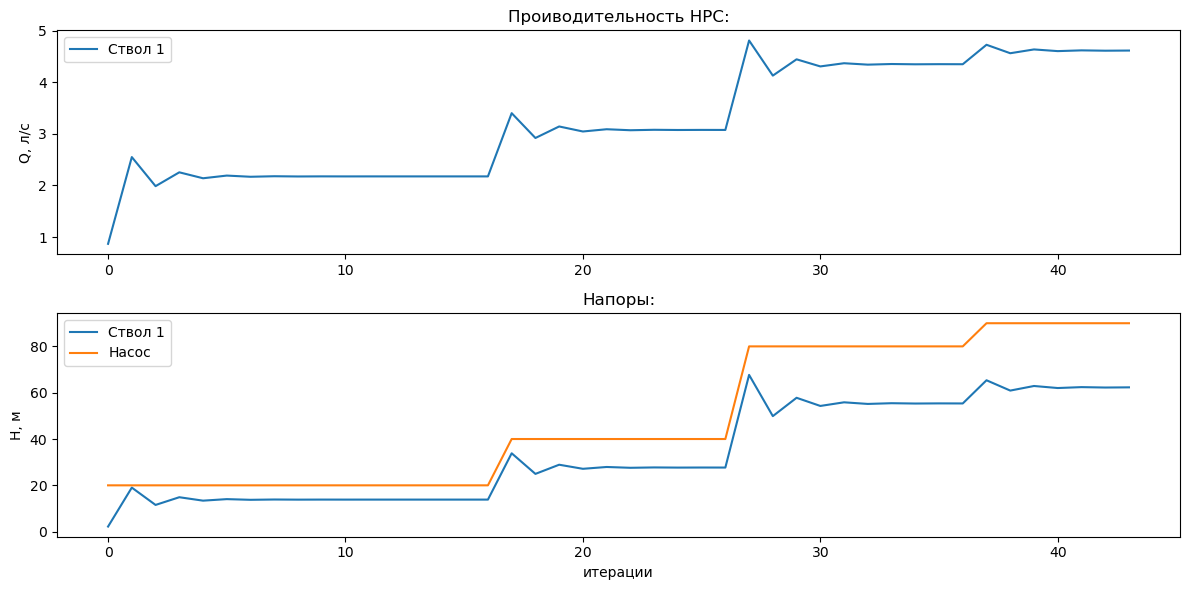

In [15]:
# Выведем графики
fig, axs = plt.subplots(2, 1, figsize=(12, 6))
axs[0].plot(watcher_nozzle1.history()['q'], label=nozzle1.name)
axs[0].set_title('Проиводительность НРС:')
axs[0].set_ylabel('Q, л/с')
axs[0].legend(fontsize=10)

axs[1].plot(watcher_nozzle1.history()['H_in'], label=nozzle1.name)
axs[1].plot(watcher_pump.history()['H_add'], label=pump.name, )
axs[1].set_title('Напоры:')
axs[1].set_xlabel('итерации')
axs[1].set_ylabel('Н, м')
axs[1].legend(fontsize=10)

fig.tight_layout()
plt.show()